In [71]:
# Load required modules
#%matplotlib inline

#from IPython.display import display

import numpy as np


from PIL import Image


#For plotting
from matplotlib import pyplot as plt
import matplotlib as mpl
plt.rcParams["animation.html"] = "jshtml"
mpl.rcParams['figure.facecolor'] = 'white'

# Import relevant modules from within GPU Ocean
from gpuocean.SWEsimulators import GPUOceanSim
from gpuocean.utils import IPythonMagic, NetCDFInitialization, PlotHelper, DrifterPlotHelper
from gpuocean.utils import Common, BathymetryAndICs
from gpuocean.drifters import LagrangianUtils

# Need pycuda to do things from scratch
import pycuda.driver as cuda


from importlib import reload

In [72]:
# Create the GPU context
%cuda_context_handler gpu_ctx

In [73]:
def imshow1(data, title=""):
    fig = plt.figure(figsize=(4, 4))
    data_max = np.max(np.abs(data))
    sp = plt.imshow(data, interpolation="none", origin='lower', 
                            cmap=plt.cm.BrBG, vmin=-data_max, vmax=data_max)
    plt.colorbar(sp, shrink=0.9)
    plt.axis('image')
    plt.title(title)

In [74]:
def imshow_image(data, title="", vmin=0, vmax=255):
    fig = plt.figure(figsize=(4, 4))
    data_max = np.max(np.abs(data))
    sp = plt.imshow(data, interpolation="none", vmin=vmin, vmax=vmax)
    plt.colorbar(sp, shrink=0.9)
    plt.axis('image')
    plt.title(title)

(365, 1103)


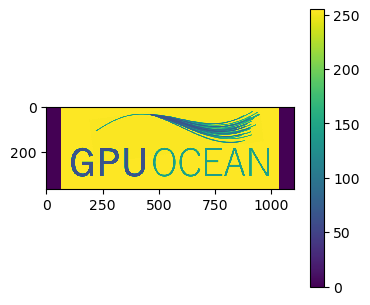

In [75]:
# Load the image
image_path = '../logo\gpuocean-logo.png'  # Replace with your image file path
input_image = Image.open(image_path)

# Convert the image to grayscale
gray_image = input_image.convert('L')

# Convert the grayscale image to a numpy array
image_array = np.array(gray_image)
print(image_array.shape)
imshow_image(image_array)


Test table lookup of exact values

(2, 2)


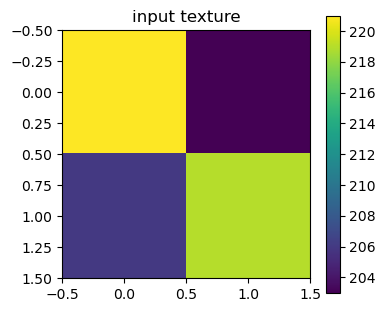

In [76]:
# Define a small domain 
nx, ny = 2, 2

nx_tex, ny_tex = 2, 2

gray_image_resized = gray_image.resize((nx_tex, ny_tex))
test_image = gray_image.resize((nx, ny))
tex_image = np.array(gray_image_resized)
original_image = np.array(gray_image_resized)

image_init = np.zeros((ny, nx))

print(tex_image.shape)

imshow_image(tex_image, "input texture", vmin=tex_image.min(), vmax=tex_image.max())

In [77]:
# GPU stuff
gpu_ctx = gpu_ctx
gpu_stream = cuda.Stream() # Different streams can in principle be run in parallel

# Define how we want to distribute the work on the GPU
# Here, we assume that each thread is responsible for moving one drifter
# Local size refers to the number of threads in each block (organized in 3D)
# global size refers to the number of blocks that will be run on the GPU (can be organized in 2D or 3D)
block_width = 16 
block_height = 16

local_size = (block_width, block_height, 1)
global_size = (int(np.ceil(nx / block_width)), int(np.ceil(ny / block_height)), 1)


# Allocate GPU memory and intialize using the 2D Array utility function, which is a wrapper around pycuda.gpuarray
image_device = Common.CUDAArray2D(gpu_stream,
                                nx, ny, 0, 0,
                                image_init)

tex_image_device = Common.CUDAArray2D(gpu_stream,
                                nx, ny, 0, 0,
                                image_init)

# Allocate GPU memory and intialize using the 2D Array utility function, which is a wrapper around pycuda.gpuarray
image_data_array_device = Common.CUDAArray2D(gpu_stream,
                                nx_tex, ny_tex, 0, 0,
                                tex_image)

# Compile cuda file
kernel = gpu_ctx.get_kernel("test_tex2d.cu", \
                                defines={'block_width': block_width, 'block_height': block_height
                                        })

# Get CUDA functions and define data types for prepared_{async_}call()
interpTestKernel = kernel.get_function("interpTest")
interpTestKernel.prepare("iiPiPiPii")

In [78]:
# Texture for image
image_texref = kernel.get_texref("data_tex")

#Upload data to GPU and bind to texture reference
image_texref.set_array(cuda.np_to_array(np.ascontiguousarray(tex_image, dtype=np.float32), order="C"))
            
# Set texture parameters
image_texref.set_filter_mode(cuda.filter_mode.LINEAR) #bilinear interpolation
image_texref.set_address_mode(0, cuda.address_mode.CLAMP) #no indexing outside domain
image_texref.set_address_mode(1, cuda.address_mode.CLAMP)
image_texref.set_flags(cuda.TRSF_NORMALIZED_COORDINATES) #Use [0, 1] indexing

In [79]:
interpTestKernel.prepared_async_call(global_size, local_size, gpu_stream,
                                               nx, ny,
                                               image_device.data.gpudata, image_device.pitch,
                                               tex_image_device.data.gpudata, tex_image_device.pitch,
                                               image_data_array_device.data.gpudata, image_data_array_device.nx, image_data_array_device.ny
                                             )

(2, 2)
(2, 2)
(2, 2)
(2, 2)
data image
 [[221 203]
 [206 219]]
sampled image
 [[221. 203.]
 [206. 219.]]
tex sampled image
 [[221. 203.]
 [206. 219.]]


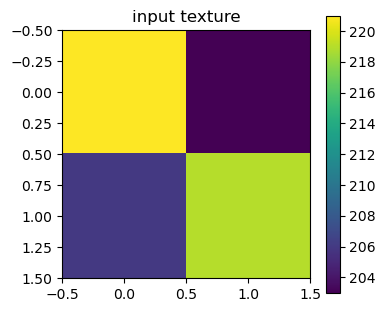

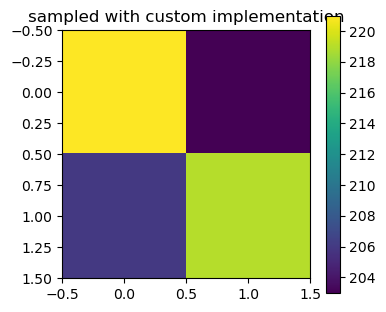

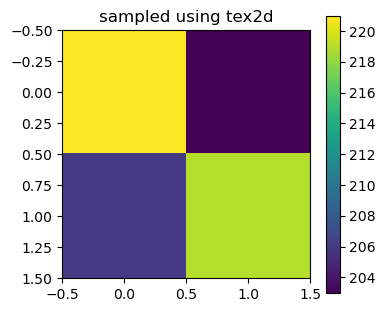

In [80]:
image_host = image_device.download(gpu_stream)
tex_image_host = tex_image_device.download(gpu_stream)
print(image_init.shape)
print(image_device.data.shape)
print(tex_image_device.data.shape)
print(image_host.shape)

vmin = np.min(np.array([np.min(tex_image), np.min(image_host), np.min(tex_image_host)]))
vmax = np.min(np.array([np.max(tex_image), np.max(image_host), np.max(tex_image_host)]))
imshow_image(tex_image, "input texture", vmin, vmax)
imshow_image(image_host, "sampled with custom implementation", vmin, vmax)
imshow_image(tex_image_host, "sampled using tex2d", vmin, vmax)

print("data image\n", tex_image)
print("sampled image\n", image_host)
print("tex sampled image\n", tex_image_host)

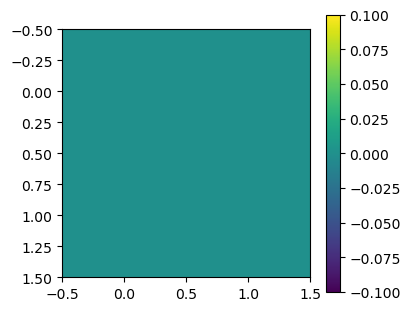

In [81]:
diff = image_host - tex_image_host
imshow_image(diff, vmin=diff.min(), vmax=diff.max())

0.0


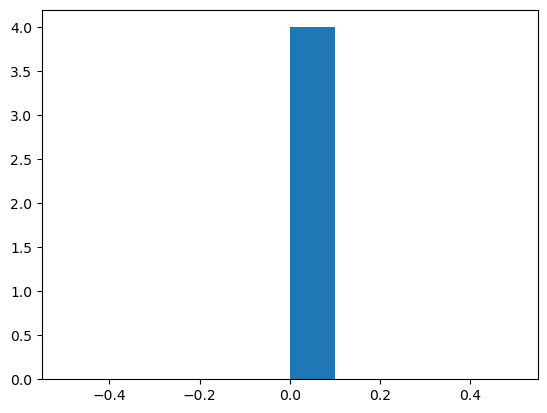

In [82]:
plt.hist(diff.flatten())
print(diff.mean())

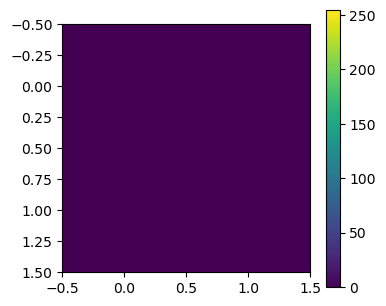

In [83]:
diff2 = image_host - original_image
imshow_image(diff2)

0.0


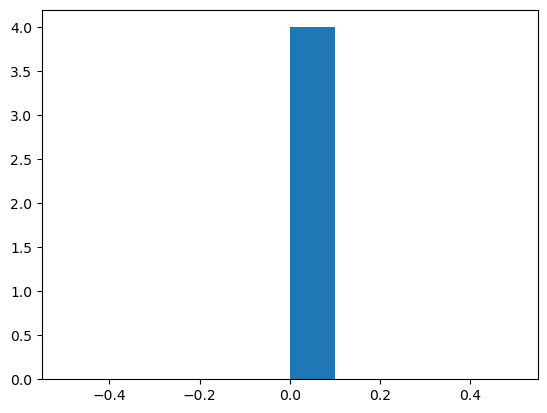

In [84]:
plt.hist(diff2.flatten())
print(diff2.mean())

Test downsampling

(3, 3)


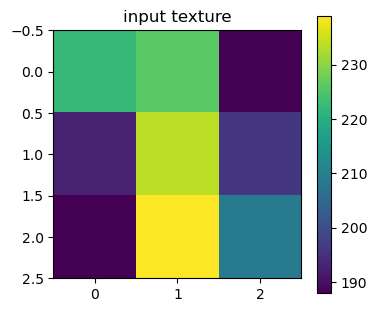

In [85]:
# Define a small domain 
nx, ny = 2, 2

nx_tex, ny_tex = 3, 3

gray_image_resized = gray_image.resize((nx_tex, ny_tex))
test_image = gray_image.resize((nx, ny))
tex_image = np.array(gray_image_resized)

image_init = np.zeros((ny, nx))

print(tex_image.shape)

imshow_image(tex_image, "input texture", vmin=tex_image.min(), vmax=tex_image.max())

In [86]:
# GPU stuff
gpu_ctx = gpu_ctx
gpu_stream = cuda.Stream() # Different streams can in principle be run in parallel

# Define how we want to distribute the work on the GPU
# Here, we assume that each thread is responsible for moving one drifter
# Local size refers to the number of threads in each block (organized in 3D)
# global size refers to the number of blocks that will be run on the GPU (can be organized in 2D or 3D)
block_width = 16 
block_height = 16

local_size = (block_width, block_height, 1)
global_size = (int(np.ceil(nx / block_width)), int(np.ceil(ny / block_height)), 1)


# Allocate GPU memory and intialize using the 2D Array utility function, which is a wrapper around pycuda.gpuarray
image_device = Common.CUDAArray2D(gpu_stream,
                                nx, ny, 0, 0,
                                image_init)

tex_image_device = Common.CUDAArray2D(gpu_stream,
                                nx, ny, 0, 0,
                                image_init)

# Allocate GPU memory and intialize using the 2D Array utility function, which is a wrapper around pycuda.gpuarray
image_data_array_device = Common.CUDAArray2D(gpu_stream,
                                nx_tex, ny_tex, 0, 0,
                                tex_image)

# Compile cuda file
kernel = gpu_ctx.get_kernel("test_tex2d.cu", \
                                defines={'block_width': block_width, 'block_height': block_height
                                        })

# Get CUDA functions and define data types for prepared_{async_}call()
interpTestKernel = kernel.get_function("interpTest")
interpTestKernel.prepare("iiPiPiPii")

In [87]:
# Texture for image
image_texref = kernel.get_texref("data_tex")

#Upload data to GPU and bind to texture reference
image_texref.set_array(cuda.np_to_array(np.ascontiguousarray(tex_image, dtype=np.float32), order="C"))
            
# Set texture parameters
image_texref.set_filter_mode(cuda.filter_mode.LINEAR) #bilinear interpolation
image_texref.set_address_mode(0, cuda.address_mode.CLAMP) #no indexing outside domain
image_texref.set_address_mode(1, cuda.address_mode.CLAMP)
image_texref.set_flags(cuda.TRSF_NORMALIZED_COORDINATES) #Use [0, 1] indexing

In [88]:
interpTestKernel.prepared_async_call(global_size, local_size, gpu_stream,
                                               nx, ny,
                                               image_device.data.gpudata, image_device.pitch,
                                               tex_image_device.data.gpudata, tex_image_device.pitch,
                                               image_data_array_device.data.gpudata, image_data_array_device.nx, image_data_array_device.ny
                                             )

(2, 2)
(2, 2)
(2, 2)
(2, 2)
data image
 [[222 226 188]
 [193 234 196]
 [188 239 209]]
sampled image
 [[222. 188.]
 [188. 209.]]
tex sampled image
 [[218.0625 199.5   ]
 [201.375  213.75  ]]


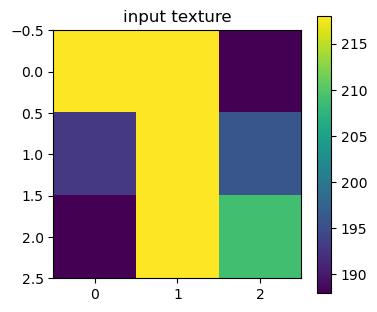

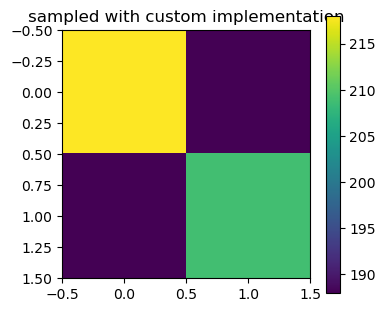

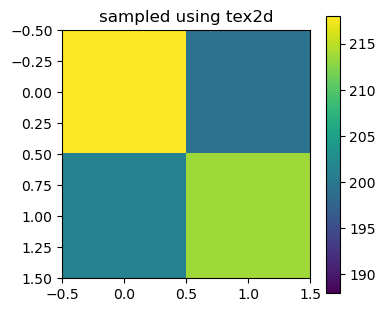

In [89]:
image_host = image_device.download(gpu_stream)
tex_image_host = tex_image_device.download(gpu_stream)
print(image_init.shape)
print(image_device.data.shape)
print(tex_image_device.data.shape)
print(image_host.shape)


vmin = np.min(np.array([np.min(tex_image), np.min(image_host), np.min(tex_image_host)]))
vmax = np.min(np.array([np.max(tex_image), np.max(image_host), np.max(tex_image_host)]))
imshow_image(tex_image, "input texture", vmin, vmax)
imshow_image(image_host, "sampled with custom implementation", vmin, vmax)
imshow_image(tex_image_host, "sampled using tex2d", vmin, vmax)

print("data image\n", tex_image)
print("sampled image\n", image_host)
print("tex sampled image\n", tex_image_host)

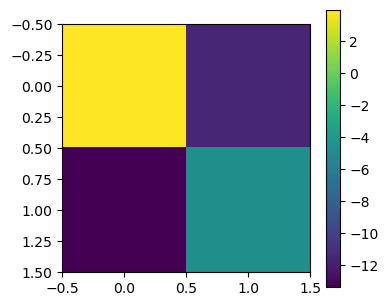

In [90]:
diff = image_host - tex_image_host
imshow_image(diff, vmin=diff.min(), vmax=diff.max())

-6.421875


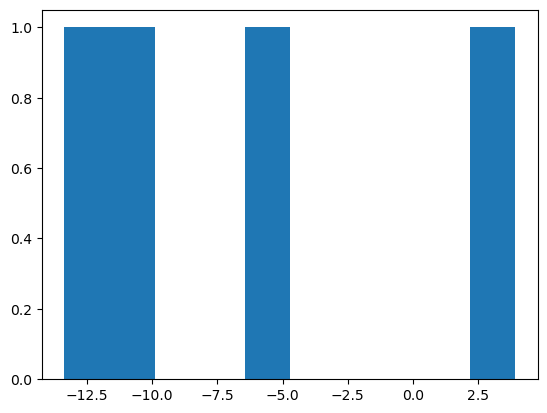

In [91]:
plt.hist(diff.flatten())
print(diff.mean())

Test upsampling

(2, 2)


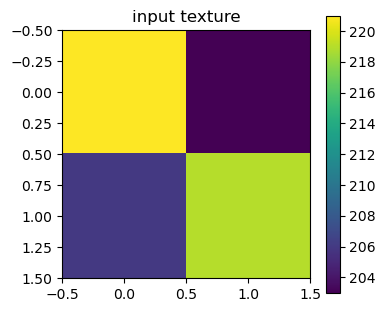

In [92]:
# Define a small domain 
nx, ny = 3, 3

nx_tex, ny_tex = 2, 2

gray_image_resized = gray_image.resize((nx_tex, ny_tex))
test_image = gray_image.resize((nx, ny))
tex_image = np.array(gray_image_resized)

image_init = np.zeros((ny, nx))

print(tex_image.shape)

imshow_image(tex_image, "input texture", vmin=tex_image.min(), vmax=tex_image.max())

In [93]:
# GPU stuff
gpu_ctx = gpu_ctx
gpu_stream = cuda.Stream() # Different streams can in principle be run in parallel

# Define how we want to distribute the work on the GPU
# Here, we assume that each thread is responsible for moving one drifter
# Local size refers to the number of threads in each block (organized in 3D)
# global size refers to the number of blocks that will be run on the GPU (can be organized in 2D or 3D)
block_width = 16 
block_height = 16

local_size = (block_width, block_height, 1)
global_size = (int(np.ceil(nx / block_width)), int(np.ceil(ny / block_height)), 1)


# Allocate GPU memory and intialize using the 2D Array utility function, which is a wrapper around pycuda.gpuarray
image_device = Common.CUDAArray2D(gpu_stream,
                                nx, ny, 0, 0,
                                image_init)

tex_image_device = Common.CUDAArray2D(gpu_stream,
                                nx, ny, 0, 0,
                                image_init)

# Allocate GPU memory and intialize using the 2D Array utility function, which is a wrapper around pycuda.gpuarray
image_data_array_device = Common.CUDAArray2D(gpu_stream,
                                nx_tex, ny_tex, 0, 0,
                                tex_image)

# Compile cuda file
kernel = gpu_ctx.get_kernel("test_tex2d.cu", \
                                defines={'block_width': block_width, 'block_height': block_height
                                        })

# Get CUDA functions and define data types for prepared_{async_}call()
interpTestKernel = kernel.get_function("interpTest")
interpTestKernel.prepare("iiPiPiPii")

In [94]:
# Texture for image
image_texref = kernel.get_texref("data_tex")

#Upload data to GPU and bind to texture reference
image_texref.set_array(cuda.np_to_array(np.ascontiguousarray(tex_image, dtype=np.float32), order="C"))
            
# Set texture parameters
image_texref.set_filter_mode(cuda.filter_mode.LINEAR) #bilinear interpolation
image_texref.set_address_mode(0, cuda.address_mode.CLAMP) #no indexing outside domain
image_texref.set_address_mode(1, cuda.address_mode.CLAMP)
image_texref.set_flags(cuda.TRSF_NORMALIZED_COORDINATES) #Use [0, 1] indexing

In [95]:
interpTestKernel.prepared_async_call(global_size, local_size, gpu_stream,
                                               nx, ny,
                                               image_device.data.gpudata, image_device.pitch,
                                               tex_image_device.data.gpudata, tex_image_device.pitch,
                                               image_data_array_device.data.gpudata, image_data_array_device.nx, image_data_array_device.ny
                                             )

(3, 3)
(3, 3)
(3, 3)
(3, 3)
data image
 [[221 203]
 [206 219]]
sampled image
 [[221.   212.   203.  ]
 [213.5  212.25 211.  ]
 [206.   212.5  219.  ]]
tex sampled image
 [[221.   212.   203.  ]
 [213.5  212.25 211.  ]
 [206.   212.5  219.  ]]


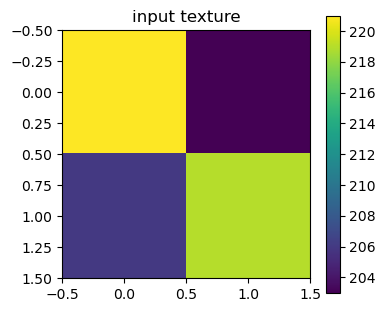

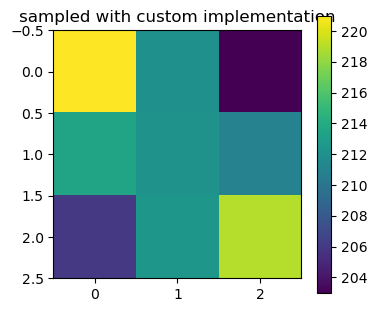

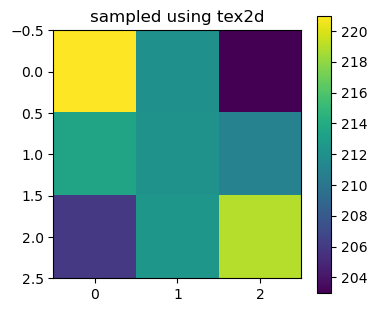

In [96]:
image_host = image_device.download(gpu_stream)
tex_image_host = tex_image_device.download(gpu_stream)
print(image_init.shape)
print(image_device.data.shape)
print(tex_image_device.data.shape)
print(image_host.shape)

vmin = np.min(np.array([np.min(tex_image), np.min(image_host), np.min(tex_image_host)]))
vmax = np.min(np.array([np.max(tex_image), np.max(image_host), np.max(tex_image_host)]))
imshow_image(tex_image, "input texture", vmin, vmax)
imshow_image(image_host, "sampled with custom implementation", vmin, vmax)
imshow_image(tex_image_host, "sampled using tex2d", vmin, vmax)

print("data image\n", tex_image)
print("sampled image\n", image_host)
print("tex sampled image\n", tex_image_host)

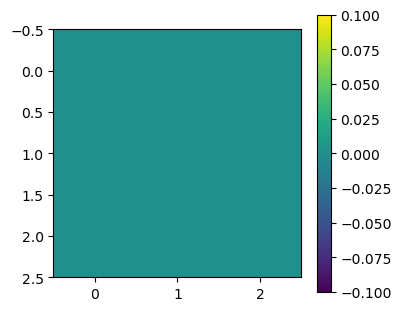

In [97]:
diff = image_host - tex_image_host
imshow_image(diff, vmin=diff.min(), vmax=diff.max())

0.0


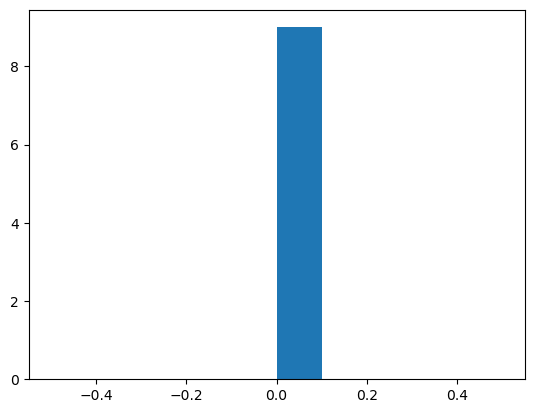

In [98]:
plt.hist(diff.flatten())
print(diff.mean())

Test upsample to larger images

(2, 2)


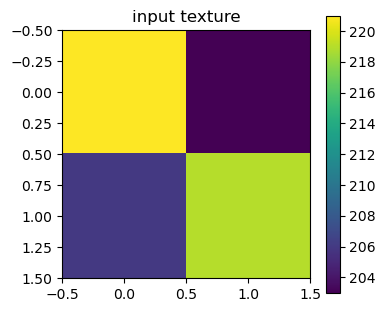

In [99]:
# Define a small domain 
nx, ny = 100, 100

nx_tex, ny_tex = 2, 2

gray_image_resized = gray_image.resize((nx_tex, ny_tex))
test_image = gray_image.resize((nx, ny))
tex_image = np.array(gray_image_resized)

image_init = np.zeros((ny, nx))

print(tex_image.shape)

imshow_image(tex_image, "input texture", vmin=tex_image.min(), vmax=tex_image.max())


In [100]:
# GPU stuff
gpu_ctx = gpu_ctx
gpu_stream = cuda.Stream() # Different streams can in principle be run in parallel

# Define how we want to distribute the work on the GPU
# Here, we assume that each thread is responsible for moving one drifter
# Local size refers to the number of threads in each block (organized in 3D)
# global size refers to the number of blocks that will be run on the GPU (can be organized in 2D or 3D)
block_width = 16 
block_height = 16

local_size = (block_width, block_height, 1)
global_size = (int(np.ceil(nx / block_width)), int(np.ceil(ny / block_height)), 1)


# Allocate GPU memory and intialize using the 2D Array utility function, which is a wrapper around pycuda.gpuarray
image_device = Common.CUDAArray2D(gpu_stream,
                                nx, ny, 0, 0,
                                image_init)

tex_image_device = Common.CUDAArray2D(gpu_stream,
                                nx, ny, 0, 0,
                                image_init)

# Allocate GPU memory and intialize using the 2D Array utility function, which is a wrapper around pycuda.gpuarray
image_data_array_device = Common.CUDAArray2D(gpu_stream,
                                nx_tex, ny_tex, 0, 0,
                                tex_image)

# Compile cuda file
kernel = gpu_ctx.get_kernel("test_tex2d.cu", \
                                defines={'block_width': block_width, 'block_height': block_height
                                        })

# Get CUDA functions and define data types for prepared_{async_}call()
interpTestKernel = kernel.get_function("interpTest")
interpTestKernel.prepare("iiPiPiPii")

In [101]:
# Texture for image
image_texref = kernel.get_texref("data_tex")

#Upload data to GPU and bind to texture reference
image_texref.set_array(cuda.np_to_array(np.ascontiguousarray(tex_image, dtype=np.float32), order="C"))
            
# Set texture parameters
image_texref.set_filter_mode(cuda.filter_mode.LINEAR) #bilinear interpolation
image_texref.set_address_mode(0, cuda.address_mode.CLAMP) #no indexing outside domain
image_texref.set_address_mode(1, cuda.address_mode.CLAMP)
image_texref.set_flags(cuda.TRSF_NORMALIZED_COORDINATES) #Use [0, 1] indexing

In [102]:
interpTestKernel.prepared_async_call(global_size, local_size, gpu_stream,
                                               nx, ny,
                                               image_device.data.gpudata, image_device.pitch,
                                               tex_image_device.data.gpudata, tex_image_device.pitch,
                                               image_data_array_device.data.gpudata, image_data_array_device.nx, image_data_array_device.ny
                                             )

(100, 100)
(100, 100)
(100, 100)
(100, 100)
data image
 [[221 203]
 [206 219]]
sampled image
 [[221.      220.81818 220.63637 ... 203.36363 203.18182 203.     ]
 [220.84848 220.66982 220.49118 ... 203.51892 203.34027 203.16162]
 [220.69698 220.52148 220.346   ... 203.67422 203.49873 203.32323]
 ...
 [206.30302 206.42801 206.55301 ... 218.42679 218.55177 218.67677]
 [206.15152 206.27966 206.40782 ... 218.58208 218.71025 218.83838]
 [206.      206.13132 206.26262 ... 218.73738 218.86868 219.     ]]
tex sampled image
 [[221. 221. 221. ... 203. 203. 203.]
 [221. 221. 221. ... 203. 203. 203.]
 [221. 221. 221. ... 203. 203. 203.]
 ...
 [206. 206. 206. ... 219. 219. 219.]
 [206. 206. 206. ... 219. 219. 219.]
 [206. 206. 206. ... 219. 219. 219.]]


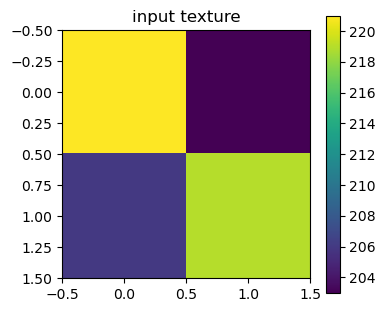

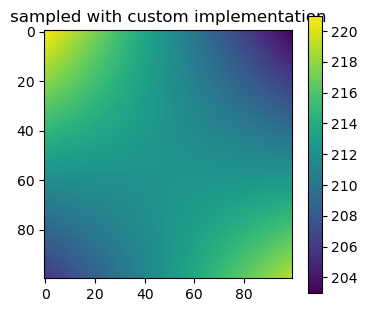

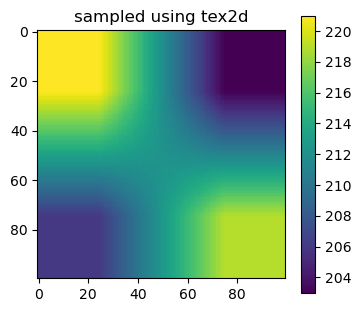

In [103]:
image_host = image_device.download(gpu_stream)
tex_image_host = tex_image_device.download(gpu_stream)
print(image_init.shape)
print(image_device.data.shape)
print(tex_image_device.data.shape)
print(image_host.shape)

vmin = np.min(np.array([np.min(tex_image), np.min(image_host), np.min(tex_image_host)]))
vmax = np.min(np.array([np.max(tex_image), np.max(image_host), np.max(tex_image_host)]))
imshow_image(tex_image, "input texture", vmin, vmax)
imshow_image(image_host, "sampled with custom implementation", vmin, vmax)
imshow_image(tex_image_host, "sampled using tex2d", vmin, vmax)

print("data image\n", tex_image)
print("sampled image\n", image_host)
print("tex sampled image\n", tex_image_host)

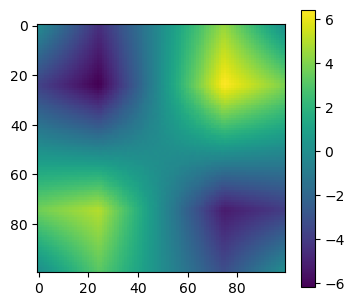

In [104]:
diff = image_host - tex_image_host
imshow_image(diff, vmin=diff.min(), vmax=diff.max())

-0.00029065248


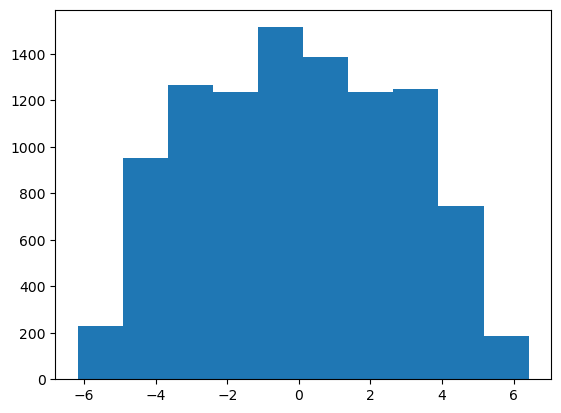

In [105]:
plt.hist(diff.flatten())
print(diff.mean())